In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/yeast.data'
try:
    yeast_data = pd.read_csv(file_path, sep=r'\s+', header=None)
    print('File yeast.data imported successfully. First 5 rows:')
    print(yeast_data.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it exists in your Google Drive.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

File yeast.data imported successfully. First 5 rows:
            0     1     2     3     4    5    6     7     8    9
0  ADT1_YEAST  0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22  MIT
1  ADT2_YEAST  0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22  MIT
2  ADT3_YEAST  0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22  MIT
3  AAR2_YEAST  0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22  NUC
4  AATM_YEAST  0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22  MIT


In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
yeast_data.head()

,0,1,2,3,4,5,6,7,8,9
0,ADT1_YEAST,0.58,0.61,0.47,0.13,0.5,0.0,0.48,0.22,MIT
1,ADT2_YEAST,0.43,0.67,0.48,0.27,0.5,0.0,0.53,0.22,MIT
2,ADT3_YEAST,0.64,0.62,0.49,0.15,0.5,0.0,0.53,0.22,MIT
3,AAR2_YEAST,0.58,0.44,0.57,0.13,0.5,0.0,0.54,0.22,NUC
4,AATM_YEAST,0.42,0.44,0.48,0.54,0.5,0.0,0.48,0.22,MIT


In [5]:
yeast_data.shape

(1484, 10)

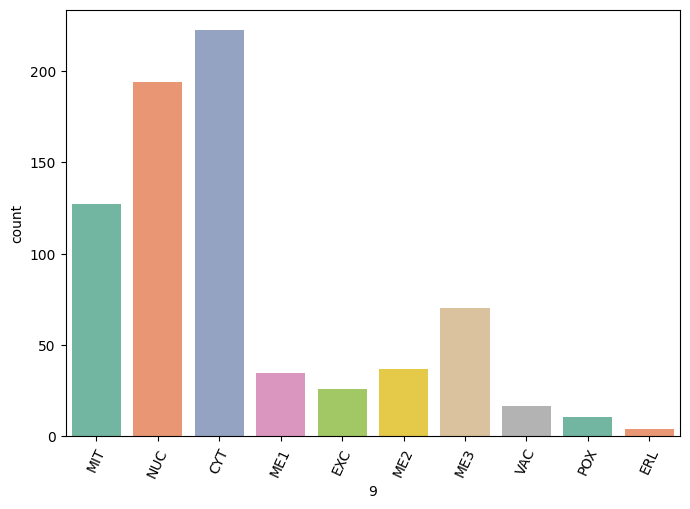

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7,5))
sns.countplot(x=yeast_data[9],data=yeast_data,palette='Set2',hue=yeast_data[9])
plt.tight_layout()
plt.xticks(rotation=65)
plt.show()

In [7]:

columns=yeast_data.columns.to_list()
columns


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [9]:
import numpy as np
correlation=yeast_data.drop(columns=[0,9]).corr()
correlation

,1,2,3,4,5,6,7,8
1,1.000000,0.581631,-0.163951,0.158175,0.064922,0.005597,0.075043,-0.124540
2,0.581631,1.000000,-0.271800,0.140314,0.060823,0.000392,0.088759,-0.102984
3,-0.163951,-0.271800,1.000000,0.059668,-0.008083,0.009378,-0.185805,-0.022043
4,0.158175,0.140314,0.059668,1.000000,-0.005931,-0.009040,-0.103591,-0.054797
5,0.064922,0.060823,-0.008083,-0.005931,1.000000,-0.009674,0.043627,0.002829
6,0.005597,0.000392,0.009378,-0.009040,-0.009674,1.000000,0.020900,-0.035659
7,0.075043,0.088759,-0.185805,-0.103591,0.043627,0.020900,1.000000,0.089690
8,-0.124540,-0.102984,-0.022043,-0.054797,0.002829,-0.035659,0.089690,1.000000


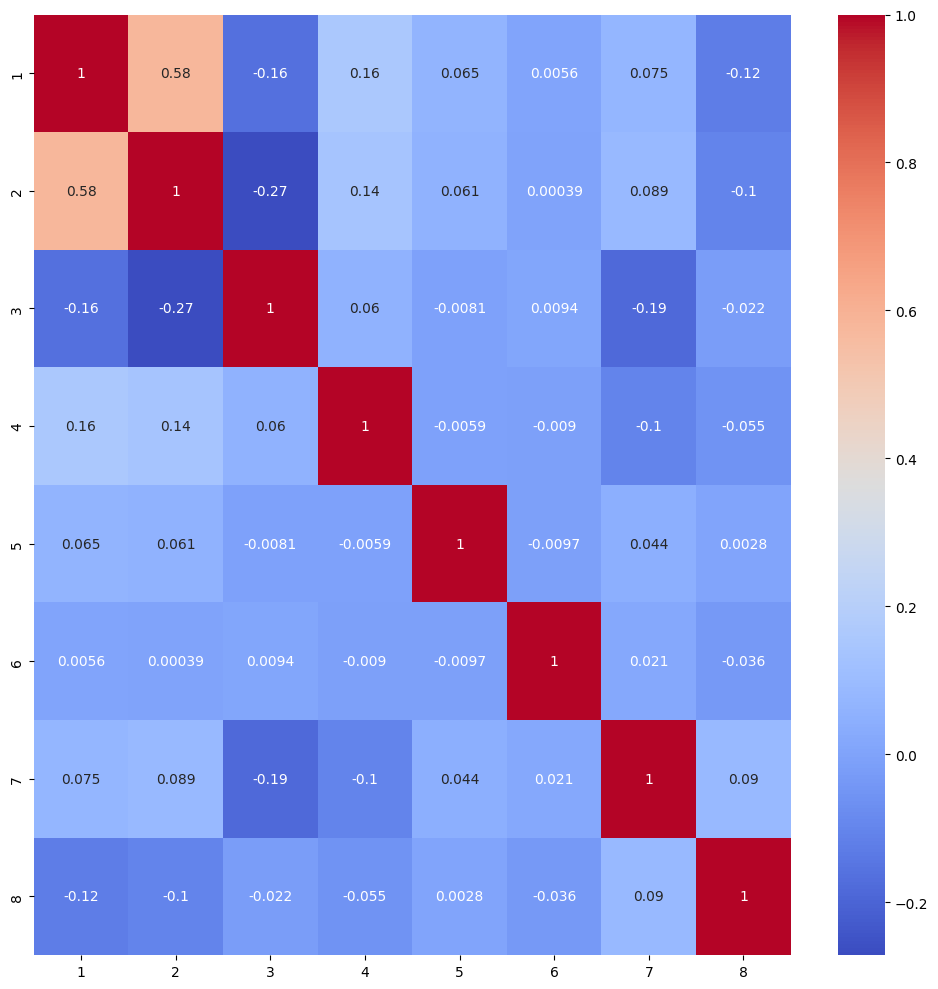

In [11]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.tight_layout()

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load dataset
df = yeast_data  # Adjust path if needed

# Separate features and target
X = df.drop(columns=[0,9], axis=1)
y = df[9]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)



In [13]:
# Wrap in DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check shapes and class info
print(" Train set:", X_train_tensor.shape)
print(" Test set:", X_test_tensor.shape)
print(" Number of Classes:", len(class_names))
print("Class Names:", class_names)

 Train set: torch.Size([1187, 8])
 Test set: torch.Size([297, 8])
 Number of Classes: 10
Class Names: ['CYT' 'ERL' 'EXC' 'ME1' 'ME2' 'ME3' 'MIT' 'NUC' 'POX' 'VAC']


In [19]:
#model formation
import torch
import torch.nn as nn

class CustomModel(nn.Module):
  def __init__(self,inputs,output,hiddens):
    super(CustomModel,self).__init__()
    self.model=nn.Sequential(
        nn.Linear(inputs,hiddens),
        nn.ReLU(),
        nn.Linear(hiddens,output)
    )

  def forward(self,x):
    return self.model(x)

In [20]:
inputs = X_train_tensor.shape[1]
hiddens = 16
output = len(class_names)

In [21]:
model=CustomModel(inputs,output,hiddens)
model

CustomModel(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [22]:
#loss function

loss_func=nn.CrossEntropyLoss()
optimimzer=torch.optim.Adam(model.parameters(),lr=0.01)


In [23]:
#traing loop
import time
training_loss=[]
training_accuracy=[]
epoches=100
start_time = time.perf_counter()
for epoch in range(epoches):
  model.train()
  logits=model(X_train_tensor)

  loss=loss_func(logits,y_train_tensor)
  training_loss.append(loss.item())

  optimimzer.zero_grad()
  loss.backward()
  optimimzer.step()

  preds=torch.argmax(logits,dim=1)
  accuracy=(preds==y_train_tensor).float().mean().item()

  if (epoch + 1) % 10 == 0:

    print(f"Epoch {epoch+1:>2} | Loss: {loss.item():.4f} | Accuracy: {accuracy*100:.2f}%")

end_time = time.perf_counter()
print(f"Training completed in {end_time - start_time:.2f} seconds")



Epoch 10 | Loss: 1.9258 | Accuracy: 31.93%
Epoch 20 | Loss: 1.5070 | Accuracy: 45.32%
Epoch 30 | Loss: 1.2978 | Accuracy: 54.17%
Epoch 40 | Loss: 1.1774 | Accuracy: 56.28%
Epoch 50 | Loss: 1.1061 | Accuracy: 58.89%
Epoch 60 | Loss: 1.0621 | Accuracy: 59.22%
Epoch 70 | Loss: 1.0360 | Accuracy: 59.90%
Epoch 80 | Loss: 1.0184 | Accuracy: 60.40%
Epoch 90 | Loss: 1.0054 | Accuracy: 61.16%
Epoch 100 | Loss: 0.9942 | Accuracy: 62.09%
Training completed in 0.25 seconds


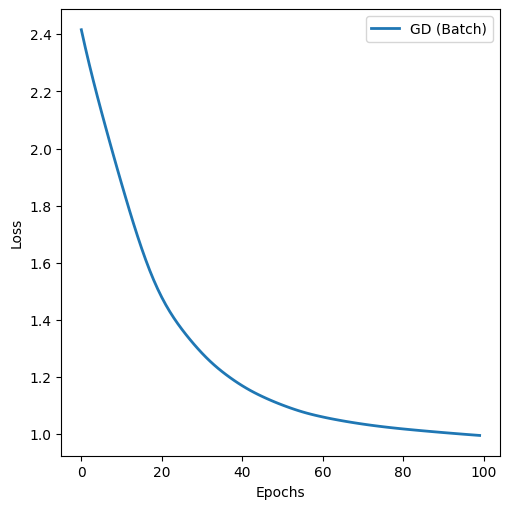

In [25]:
plt.figure(figsize=(5,5))
plt.plot(range(epoches), training_loss, label="GD (Batch)", linewidth=2)
plt.tight_layout()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import torch


model_save_path = '/content/yeast_model.pth'


torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to {model_save_path}")



Model saved successfully to /content/yeast_model.pth
